# Eksplorasi Data Listing Produk Tokopedia

Tujuan notebook ini adalah mengenal data apa adanya dan mencatat masalah yang ditemukan. Belum ada pembersihan data di sini. Daftar masalah di akhir notebook menjadi rencana kerja untuk tahap data prep.

Dataset: `Dataset/raw/produk_tokopedia.csv`

## 1. Muat data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = pd.read_csv("../Dataset/raw/produk_tokopedia.csv")
df.head()

,Nama Produk,Nama Toko,Lokasi Toko,Terjual,Jumlah Ulasan,Rating,Harga (IDR),Diskon (%),Produk URL
0,Raw Food Beef Bone-In / Daging Giling / Dog Fo...,Lazy Dog Supply,Jakarta Selatan,1rb+ terjual,10 ulasan,5.0,35000,0.0,https://www.tokopedia.com/lazy-dog-supply/raw-...
1,Turkey Meat ONLY NO BONE - 1KG - Daging Kalkun...,RumahBully,Jakarta Timur,250+ terjual,NaN,5.0,79999,0.0,https://www.tokopedia.com/rumahbully/turkey-me...
2,Chicken mix Salmon Raw Food ayam mix salmon ma...,RumahBully,Jakarta Barat,26 terjual,NaN,5.0,33000,0.0,https://www.tokopedia.com/rumahbully/chicken-m...
3,PROMO BULANAN - SOSIS CHOP PREMIUM RAW - DOG F...,RumahBully,Tangerang Selatan,100+ terjual,NaN,5.0,29900,0.0,https://www.tokopedia.com/rumahbully/promo-bul...
4,Premium Dog Food / Daging Sapi Giling / Raw Fo...,RumahBully,Jakarta Selatan,1rb+ terjual,NaN,5.0,39000,0.0,https://www.tokopedia.com/rumahbully/premium-d...


In [2]:
# Gaya grafik yang dipakai di seluruh notebook
BIRU = "#2a78d6"     # warna utama
ORANYE = "#eb6834"   # penanda hal yang perlu diperhatikan
ABU = "#c8c6bf"      # data pembanding
TEKS = "#52514e"     # warna label dan anotasi

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#8a8983",
    "axes.labelcolor": TEKS,
    "xtick.color": TEKS,
    "ytick.color": TEKS,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
})


def rupiah(x):
    return "Rp" + f"{x:,.0f}".replace(",", ".")

Catatan:

Data berisi 29.519 baris dan 9 kolom. Setiap baris adalah satu listing produk dengan informasi nama produk, nama toko, lokasi toko, jumlah terjual, jumlah ulasan, rating, harga, diskon, dan URL.

Dataset ini tidak punya kolom kategori produk. Kalau nanti ingin membandingkan antar kategori, kategorinya harus dibuat sendiri dari teks `Nama Produk`.

## 2. Struktur data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29519 entries, 0 to 29518
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Nama Produk    29519 non-null  str    
 1   Nama Toko      29469 non-null  str    
 2   Lokasi Toko    29379 non-null  str    
 3   Terjual        29290 non-null  str    
 4   Jumlah Ulasan  28260 non-null  str    
 5   Rating         29519 non-null  float64
 6   Harga (IDR)    29519 non-null  int64  
 7   Diskon (%)     29519 non-null  float64
 8   Produk URL     29519 non-null  str    
dtypes: float64(2), int64(1), str(6)
memory usage: 7.3 MB


Catatan:

Kolom `Rating`, `Harga (IDR)`, dan `Diskon (%)` sudah bertipe angka. Kolom `Terjual` dan `Jumlah Ulasan` masih bertipe teks (`str`) karena isinya seperti "100+ terjual" dan "10 ulasan". Keduanya harus diubah menjadi angka supaya bisa dihitung, diurutkan, atau dikorelasikan.

Beberapa kolom punya `Non-Null Count` di bawah 29.519, artinya ada nilai kosong. Detailnya ada di bagian 3.

## 3. Nilai kosong

In [4]:
df.isna().sum()

Nama Produk         0
Nama Toko          50
Lokasi Toko       140
Terjual           229
Jumlah Ulasan    1259
Rating              0
Harga (IDR)         0
Diskon (%)          0
Produk URL          0
dtype: int64

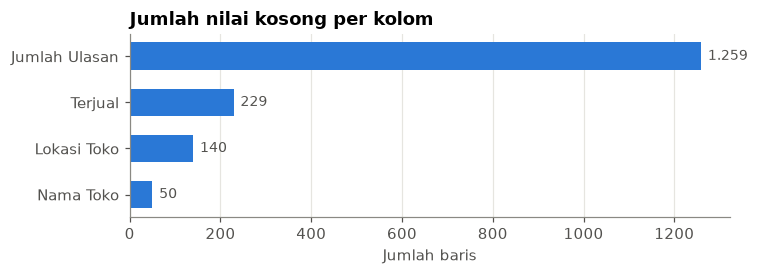

In [5]:
kosong = df.isna().sum()
kosong = kosong[kosong > 0].sort_values()

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(kosong.index, kosong.values, color=BIRU, height=0.6)
for y, v in enumerate(kosong.values):
    ax.text(v + 15, y, f"{v:,}".replace(",", "."), va="center", fontsize=9, color=TEKS)
ax.set_title("Jumlah nilai kosong per kolom")
ax.set_xlabel("Jumlah baris")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Catatan:

Ada empat kolom yang punya nilai kosong: `Jumlah Ulasan` (1.259 baris), `Terjual` (229), `Lokasi Toko` (140), dan `Nama Toko` (50). Jumlahnya kecil, paling besar sekitar 4% dari data.

Angka ini belum mencakup semua data yang sebenarnya kosong. Ada juga nilai kosong yang ditulis sebagai teks, seperti "Tidak tersedia" atau "Unknown", sehingga tidak terhitung oleh `isna()`. Rinciannya ada di bagian 6.

## 4. Ringkasan kolom angka

In [6]:
df.describe()

,Rating,Harga (IDR),Diskon (%)
count,29519.000000,2.951900e+04,29519.000000
mean,4.571793,1.039545e+06,11.235983
std,1.243845,1.101262e+07,20.376351
min,0.000000,0.000000e+00,0.000000
25%,4.800000,3.550000e+04,0.000000
50%,5.000000,9.900000e+04,0.000000
75%,5.000000,3.185075e+05,14.000000
max,5.000000,9.000000e+08,97.000000


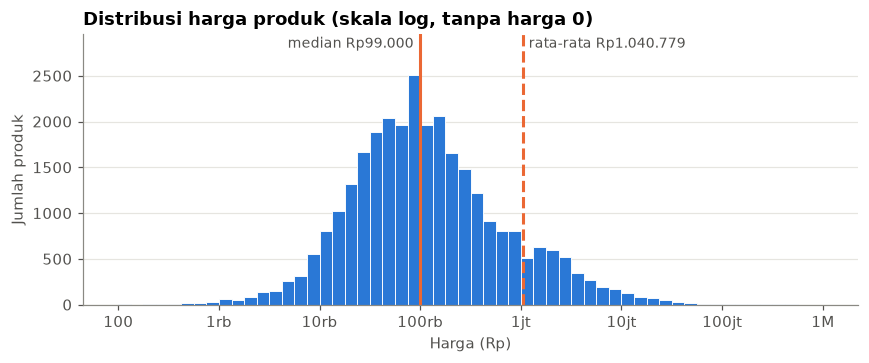

In [7]:
harga = df.loc[df["Harga (IDR)"] > 0, "Harga (IDR)"]

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(harga, bins=np.logspace(2, 9, 57), color=BIRU, edgecolor="white", linewidth=0.6)
ax.set_xscale("log")
ax.set_xticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9])
ax.set_xticklabels(["100", "1rb", "10rb", "100rb", "1jt", "10jt", "100jt", "1M"])
ax.minorticks_off()

ax.axvline(harga.median(), color=ORANYE, linewidth=2)
ax.axvline(harga.mean(), color=ORANYE, linewidth=2, linestyle="--")
ymax = ax.get_ylim()[1] * 1.12
ax.set_ylim(top=ymax)
ax.text(harga.median() / 1.15, ymax * 0.95, "median " + rupiah(harga.median()), ha="right", color=TEKS, fontsize=9)
ax.text(harga.mean() * 1.15, ymax * 0.95, "rata-rata " + rupiah(harga.mean()), ha="left", color=TEKS, fontsize=9)

ax.set_title("Distribusi harga produk (skala log, tanpa harga 0)")
ax.set_xlabel("Harga (Rp)")
ax.set_ylabel("Jumlah produk")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

Catatan:

Rata-rata harga sekitar Rp1,04 juta, sedangkan median hanya Rp99.000. Artinya distribusi harga sangat miring ke kanan: sebagian besar produk murah, tetapi ada segelintir produk yang sangat mahal sehingga menarik rata-rata ke atas. Karena itu, analisis harga sebaiknya memakai median dan grafiknya memakai skala log, seperti grafik di atas.

Harga minimum adalah 0, yang tidak masuk akal untuk produk yang dijual. Harga maksimum Rp900 juta. Detailnya ada di bagian 8.

Rating minimum 0, padahal rating di Tokopedia berkisar 1 sampai 5. Median rating 5.0 dan kuartil bawahnya 4.8, jadi hampir semua produk ber-rating tinggi. Artinya rating kurang bisa membedakan produk yang bagus dan yang biasa saja.

Diskon: median 0 dan sekitar 34,5% produk punya diskon, dengan diskon tertinggi 97%.

## 5. Duplikat

In [8]:
print("Baris yang persis sama :", df.duplicated().sum())
print("URL produk yang dobel  :", df.duplicated("Produk URL").sum())

Baris yang persis sama : 416
URL produk yang dobel  : 781


In [9]:
# Contoh URL yang dipakai oleh lebih dari satu baris
df["Produk URL"].value_counts().head(8)

Produk URL
https://www.tokopedia.com                         18
https://www.tokopedia.com/threedots               11
https://www.tokopedia.com/semarnusantara           8
https://www.tokopedia.com/wingsindonesia           8
https://www.tokopedia.com/                         5
https://www.tokopedia.com/gotoliving               5
https://www.tokopedia.com/wardahbeautyid           5
https://www.tokopedia.com/hariharikaryabersama     5
Name: count, dtype: int64

In [10]:
# Jenis halaman yang dituju URL.
# URL produk berbentuk tokopedia.com/<toko>/<produk>, URL toko hanya tokopedia.com/<toko>
jalur = (
    df["Produk URL"]
    .str.replace(r"^https?://(www\.)?tokopedia\.com/?", "", regex=True)
    .str.split("?").str[0]
    .str.strip("/")
)
jenis_url = np.select(
    [jalur == "", ~jalur.str.contains("/")],
    ["beranda Tokopedia", "halaman toko"],
    default="halaman produk",
)
pd.Series(jenis_url).value_counts()

halaman produk       19540
halaman toko          9956
beranda Tokopedia       23
Name: count, dtype: int64

Catatan:

Ada 416 baris yang isinya persis sama di semua kolom. Baris seperti ini jelas duplikat dan aman dibuang.

Jumlah URL yang dobel lebih besar, yaitu 781. Penyebabnya, kolom `Produk URL` tidak selalu berisi link produk. Sekitar 9.956 baris (34%) hanya berisi link halaman toko, misalnya `tokopedia.com/ace`, dan 23 baris hanya berisi `tokopedia.com`. Akibatnya, produk-produk berbeda dari toko yang sama bisa tercatat dengan URL yang sama. Contohnya, URL `https://www.tokopedia.com` saja muncul di 18 baris dengan produk yang berbeda-beda.

Kesimpulannya, `Produk URL` tidak bisa dipakai sebagai penanda unik produk. Kalau duplikat dibuang berdasarkan URL, produk yang sebenarnya berbeda ikut terbuang.

## 6. Kolom teks yang seharusnya angka

In [11]:
df["Terjual"].value_counts().head(20)

Terjual
100+ terjual     3184
0 terjual        2621
250+ terjual     1539
1rb+ terjual     1395
1 terjual        1317
500+ terjual     1158
50+ terjual       987
30+ terjual       959
2 terjual         959
10rb+ terjual     928
3 terjual         758
40+ terjual       719
5 terjual         630
2rb+ terjual      626
750+ terjual      570
4 terjual         552
6 terjual         461
60+ terjual       453
7 terjual         395
70+ terjual       379
Name: count, dtype: int64

In [12]:
# Nilai Terjual yang tidak berpola "<angka> terjual"
pola_angka = df["Terjual"].str.lower().str.match(r"^[\d.,\s]+(rb|jt|k)?\+?\s*terjual", na=False)
df.loc[~pola_angka & df["Terjual"].notna(), "Terjual"].value_counts()

Terjual
0                         73
Unknown                   23
Tidak tersedia            19
Baru                      17
Tidak disebutkan          16
Terjual                   14
Terlaris                   8
Tidak ada data             7
tersedia                   7
terjual                    6
Not available              4
Terjual tidak tersedia     3
Stock Tersedia             2
Terjual banyak             2
Best Seller                2
Terjual Sebagian           2
Preorder                   1
111 rating                 1
223 sold                   1
5 rating                   1
152 rating                 1
Terjual Banyak             1
Terbatas                   1
58 rating                  1
3 rating                   1
150 stok                   1
ribuan terjual             1
4 ulasan                   1
640 sold                   1
910 sold                   1
2.538 rating               1
103 rating                 1
Tersedia                   1
Ribuan terjual             1
Name: 

In [13]:
df["Jumlah Ulasan"].value_counts().head(20)

Jumlah Ulasan
0 ulasan       8691
1 ulasan       1085
100+ ulasan     817
2 ulasan        805
5 ulasan        780
10 ulasan       698
15 ulasan       562
3 ulasan        542
50 ulasan       461
4 ulasan        455
12 ulasan       430
20 ulasan       375
100 ulasan      369
50+ ulasan      363
8 ulasan        362
30 ulasan       361
500+ ulasan     352
40 ulasan       334
1rb+ ulasan     318
250+ ulasan     290
Name: count, dtype: int64

In [14]:
# Variasi penulisan angka ribuan di Jumlah Ulasan
ulasan = df["Jumlah Ulasan"].dropna()
ulasan[ulasan.str.contains(r"\d[.,]\d|\dk", case=False)].value_counts().head(20)

Jumlah Ulasan
1.2rb ulasan      50
1.5rb ulasan      15
2.1rb ulasan      13
10.000+ ulasan     7
2.5rb ulasan       6
4.4 rb ulasan      6
1.000+ ulasan      5
1k+ ulasan         5
1.5rb+ ulasan      5
3.5rb ulasan       4
1.8rb ulasan       4
1.1rb ulasan       4
5.000+ ulasan      4
3,2 rb ulasan      3
1k ulasan          3
7.426 ulasan       2
3.2rb ulasan       2
1.7 rb ulasan      2
2.4rb ulasan       2
4.9k+ ulasan       2
Name: count, dtype: int64

Catatan:

Kolom `Terjual` punya banyak format untuk menulis jumlah: "26 terjual", "100+ terjual", "1rb+ terjual", "4 rb+ Terjual" (dengan spasi dan huruf kapital), "3.5rb terjual", "4.95rb+ terjual", "1000+ terjual", dan "1jt+ terjual". Artinya ada satuan rb (ribu) dan jt (juta), serta tanda + yang berarti "lebih dari". Jadi "1rb+" berarti minimal 1.000, bukan tepat 1.000. Setelah dikonversi, angka ini harus dibaca sebagai batas bawah.

Ada 223 nilai `Terjual` yang tidak berpola "<angka> terjual". Sebanyak 73 di antaranya hanya berisi angka "0", dan 3 memakai kata "sold" (misalnya "223 sold"). Keduanya masih bisa diubah menjadi angka. Sisanya, sekitar 147 nilai, bukan jumlah terjual. Isinya bermacam-macam: label toko seperti "Best Seller", "Terlaris", dan "Baru"; keterangan kosong seperti "Unknown", "Tidak tersedia", dan "Tidak disebutkan"; serta data yang sepertinya berasal dari kolom lain, seperti "103 rating" dan "150 stok". Nilai "223 sold" masih bisa dipakai karena artinya sama dengan terjual. Nilai lain yang tidak bisa diartikan sebagai jumlah terjual perlu dijadikan kosong.

Kolom `Jumlah Ulasan` punya masalah yang lebih tersembunyi, yaitu arti tanda titik yang tidak konsisten. Pada "1.000 ulasan" dan "7.426 ulasan", titik adalah pemisah ribuan (seribu, tujuh ribu). Pada "1.2rb ulasan", titik adalah tanda desimal (seribu dua ratus). Koma juga dipakai sebagai desimal, seperti pada "1,3 rb ulasan", dan ada satuan K seperti "1.5K ulasan". Kalau semua titik dibuang begitu saja, "1.2rb" akan terbaca 12 ribu. Aturan konversinya harus melihat ada atau tidaknya satuan rb/K di belakang angka.

`Jumlah Ulasan` juga punya nilai "Tidak tersedia" (113 baris) dan setidaknya satu nilai "ulasan toko", yang merupakan jumlah ulasan toko, bukan ulasan produk.

## 7. Rating

In [15]:
df["Rating"].value_counts().head(10)

Rating
5.0    15693
4.9     5791
4.8     3046
0.0     1988
4.7     1325
4.6      531
4.5      439
4.0      200
4.4      160
4.3      126
Name: count, dtype: int64

In [16]:
df[df["Rating"] == 0][["Nama Produk", "Terjual", "Jumlah Ulasan"]].head(10)

,Nama Produk,Terjual,Jumlah Ulasan
25,Rabbit All In - Dog & Cat Super Raw Food - Dag...,0 terjual,0 ulasan
52,Pure Turkey Meat Dog Food Cat Food 1kg,0 terjual,0 ulasan
440,Promo jas hujan dewasa pria wanita setelan baj...,0 terjual,0 ulasan
458,RAFATAR-Tas Ransel Sekolah Anak PREMIUM 2023,0 terjual,0 ulasan
479,KEDAIBUTIK (495) Tas Ransel Anak Terbaru 2024 ...,0 terjual,0 ulasan
480,LMB Tas Anak Sekolah Laki Laki SD Import Bahan...,0 terjual,0 ulasan
482,Jansport Tas Ransel JS Motif Banana Kekinian B...,0 terjual,0 ulasan
483,Ransel Premium Tas Sekolah Anak SD SMP Laki La...,0 terjual,0 ulasan
500,KANEMOCHI BAG RANSEL 01 Tas Sekolah Anak Motif...,0 terjual,0 ulasan
501,INFICLO Tas Ransel Sekolah Anak Cowok Navy Bah...,0 terjual,0 ulasan


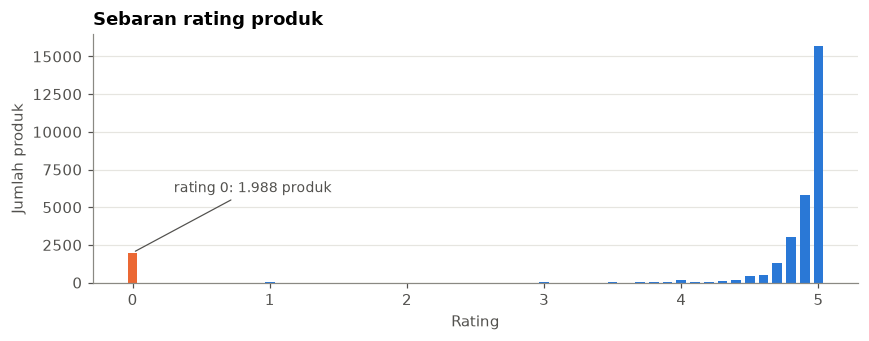

In [17]:
sebaran = df["Rating"].value_counts().sort_index()
warna = [ORANYE if r == 0 else BIRU for r in sebaran.index]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(sebaran.index, sebaran.values, width=0.07, color=warna)
jumlah_nol = int(sebaran.get(0.0, 0))
ax.annotate(
    f"rating 0: {jumlah_nol:,} produk".replace(",", "."),
    xy=(0, jumlah_nol), xytext=(0.3, 6000),
    color=TEKS, fontsize=9, arrowprops=dict(arrowstyle="-", color=TEKS, lw=0.8),
)
ax.set_title("Sebaran rating produk")
ax.set_xlabel("Rating")
ax.set_ylabel("Jumlah produk")
ax.set_xticks(range(6))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

Catatan:

Ada 1.988 produk dengan rating 0.0. Sebagian besar dari produk ini belum pernah terjual ("0 terjual") dan belum punya ulasan ("0 ulasan"). Jadi rating 0 bukan berarti produknya jelek, tetapi produk tersebut belum dinilai sama sekali. Kalau tetap dihitung sebagai angka 0, rata-rata rating akan turun secara tidak wajar. Di tahap data prep, rating 0 sebaiknya diubah menjadi kosong.

Selain itu, rating sangat terkonsentrasi di angka tinggi: 15.693 produk ber-rating 5.0 dan hampir semua sisanya di 4.7 sampai 4.9. Perbedaan kecil seperti 4.8 dan 4.9 sulit dijadikan dasar kesimpulan.

Hal lain yang perlu diingat: ada 6.939 produk dengan "0 ulasan" tetapi rating-nya di atas 0. Ini tidak selalu salah, karena pembeli bisa memberi bintang tanpa menulis ulasan. Namun artinya `Jumlah Ulasan` tidak sama dengan jumlah orang yang memberi rating.

## 8. Harga ekstrem

In [18]:
df.nlargest(10, "Harga (IDR)")[["Nama Produk", "Harga (IDR)"]]

,Nama Produk,Harga (IDR)
888,Hyundai Palisade Signature 4x2,900000000
7836,Mitsubishi Pajero Sport DAKAR 4x4 AT - Promo,610205000
880,Hyundai IONIQ 5 Signature Long Range,479000000
885,Mitsubishi Xforce Ultimate 4X2 AT,421900000
7850,Mitsubishi Pajero Sport Dakar (4x2) AT - 400JT...,400000000
884,Mitsubishi Xforce Exceed 4X2 AT,389900000
891,Mitsubishi New Xpander Cross Elite Limited Edi...,371000000
886,Wuling Binguo EV Standard Range 333 KM,348000000
890,Wuling Air EV Long Range,315000000
892,Hyundai Stargazer Prime IVT,311800000


In [19]:
df.nsmallest(10, "Harga (IDR)")[["Nama Produk", "Harga (IDR)"]]

,Nama Produk,Harga (IDR)
99,BISA COD Manset Bogaboo - Manset Tangan Jempol...,0
3330,Tabitha Lemari Lipat Portable Serbaguna (Multi...,0
3782,"Plafon Pvc terbaik DP-19,20 - 56 terlengkap",0
5924,Press Play ATLAS,0
5925,Sades Ryunix Kojin MX10,0
5926,Fantech Helios II Pro S,0
5927,Rexus DAXA Air V,0
5928,Vortexseries Inno X3 Pro,0
8263,GOL Baby 3 pc Premium Glass Jar Baby Glass Foo...,0
8422,Bagus Sapu Lantai (Floor Broom) Tipe 339,0


In [20]:
print("Harga 0          :", (df["Harga (IDR)"] == 0).sum())
print("Harga < Rp1.000  :", ((df["Harga (IDR)"] > 0) & (df["Harga (IDR)"] < 1_000)).sum())
print("Harga >= Rp100 jt:", (df["Harga (IDR)"] >= 100_000_000).sum())

Harga 0          : 35
Harga < Rp1.000  : 93
Harga >= Rp100 jt: 31


Catatan:

Ada 35 produk dengan harga 0, misalnya kursi lipat, sapu, dan mouse gaming. Produk seperti ini jelas tidak gratis, jadi harganya kemungkinan gagal terambil saat scraping. Harga 0 perlu dianggap tidak valid.

Produk dengan harga di bawah Rp1.000 (93 produk) masih masuk akal, contohnya stiker, cetak foto satuan, sabun hotel, dan baut. Jadi harga murah tidak otomatis salah.

Di sisi lain, ada 31 produk seharga Rp100 juta ke atas. Sebagian besar adalah mobil (Hyundai, Mitsubishi, Toyota, Wuling), ditambah motor, jam Rolex, dan emas batangan. Harganya wajar untuk barangnya, jadi datanya valid. Namun produk-produk ini sangat jauh dari mayoritas, sehingga bisa mendistorsi rata-rata. Nanti perlu diputuskan apakah dipisahkan dari analisis atau cukup memakai median.

## 9. Lokasi toko

In [21]:
print("Jumlah lokasi unik:", df["Lokasi Toko"].nunique())
df["Lokasi Toko"].value_counts().head(20)

Jumlah lokasi unik: 322


Lokasi Toko
Jakarta                            4083
Indonesia                          2834
Jakarta Barat                      2363
Jakarta Pusat                      1525
Jakarta Utara                      1371
Kab. Tangerang                      949
Jakarta Selatan                     894
Surabaya                            877
Kota Bandung                        805
Jakarta Timur                       783
Kota Administrasi Jakarta Barat     735
Tangerang                           727
Bandung                             716
Kota Tangerang                      660
Kota Surabaya                       628
Kab. Bandung                        584
Kota Administrasi Jakarta Utara     468
Kota Bekasi                         385
Kab. Bekasi                         385
Kota Tangerang Selatan              344
Name: count, dtype: int64

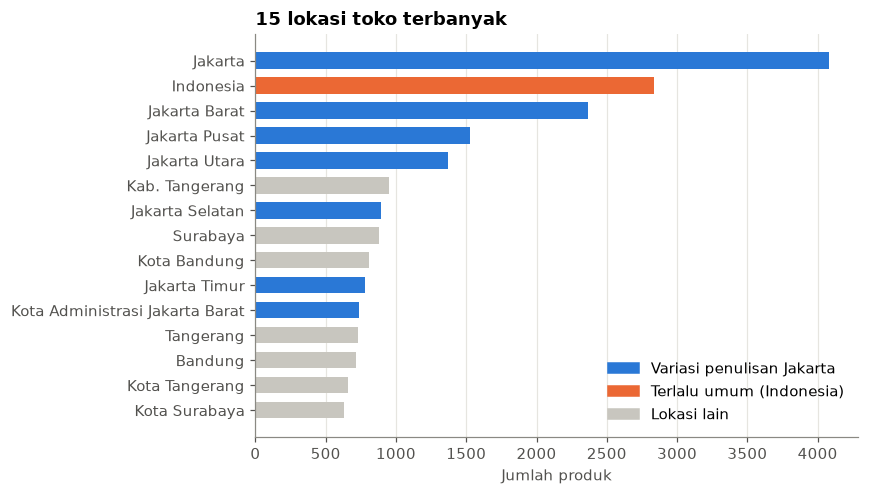

In [22]:
top_lokasi = df["Lokasi Toko"].value_counts().head(15).sort_values()


def warna_lokasi(nama):
    if nama == "Indonesia":
        return ORANYE
    if "Jakarta" in nama:
        return BIRU
    return ABU


fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(top_lokasi.index, top_lokasi.values, color=[warna_lokasi(n) for n in top_lokasi.index], height=0.65)
ax.set_title("15 lokasi toko terbanyak")
ax.set_xlabel("Jumlah produk")
ax.grid(axis="y", visible=False)
ax.legend(
    handles=[
        Patch(color=BIRU, label="Variasi penulisan Jakarta"),
        Patch(color=ORANYE, label="Terlalu umum (Indonesia)"),
        Patch(color=ABU, label="Lokasi lain"),
    ],
    loc="lower right", frameon=False,
)
plt.tight_layout()
plt.show()

Catatan:

Ada 322 lokasi unik, tetapi banyak yang sebenarnya merujuk ke tempat yang sama dengan penulisan berbeda, dan level wilayahnya juga tidak seragam:

- "Jakarta" (4.083 produk) berdiri sendiri, terpisah dari "Jakarta Barat", "Jakarta Pusat", dan seterusnya.
- "Jakarta Barat" (2.363) dan "Kota Administrasi Jakarta Barat" (735) adalah wilayah yang sama.
- "Bandung", "Kota Bandung", dan "Kab. Bandung" muncul sebagai tiga lokasi. Kota Bandung dan Kabupaten Bandung memang wilayah berbeda, sehingga "Bandung" saja menjadi ambigu. Pola yang sama terjadi pada Tangerang dan Bekasi.

Lokasi "Indonesia" muncul di 2.834 baris (9,6%). Lokasi ini tidak informatif untuk analisis geografis.

Supaya perbandingan antarwilayah adil, lokasi perlu diseragamkan ke level yang lebih tinggi, misalnya provinsi atau kota besar. Baris berlokasi "Indonesia" dipisahkan dari analisis lokasi.

## Ringkasan masalah yang ditemukan

Daftar ini menjadi rencana kerja untuk tahap data prep.

1. Kolom `Terjual` dan `Jumlah Ulasan` masih berupa teks dan harus dikonversi ke angka. Aturannya perlu menangani satuan rb, jt, dan K, tanda +, spasi, dan huruf kapital. Karena tanda +, hasil konversi adalah batas bawah, bukan angka pasti.
2. Arti tanda titik tidak konsisten di `Jumlah Ulasan`. "1.000" memakai titik sebagai pemisah ribuan, sedangkan "1.2rb" memakai titik sebagai desimal. Koma juga dipakai sebagai desimal ("1,3 rb").
3. Sekitar 147 nilai `Terjual` bukan jumlah terjual, seperti "Best Seller", "Unknown", "103 rating", dan "150 stok". Di `Jumlah Ulasan` ada 113 nilai "Tidak tersedia". Nilai seperti ini dijadikan kosong. "sold" masih bisa diartikan sebagai terjual.
4. Ada nilai kosong di `Jumlah Ulasan` (1.259), `Terjual` (229), `Lokasi Toko` (140), dan `Nama Toko` (50).
5. Rating 0 muncul di 1.988 produk dan artinya belum dinilai, bukan rating terburuk. Nilai ini dijadikan kosong.
6. Ada 35 produk berharga 0 yang tidak valid.
7. Ada 31 produk berharga Rp100 juta ke atas (mobil, motor, jam mewah, emas). Datanya valid tetapi merupakan outlier ekstrem. Distribusi harga sangat miring, sehingga analisis memakai median dan skala log.
8. Ada 416 baris yang persis sama, yang aman dibuang. `Produk URL` tidak bisa menjadi penanda unik karena 34% di antaranya hanya berisi link halaman toko.
9. Penulisan `Lokasi Toko` tidak seragam (misalnya "Jakarta Barat" dan "Kota Administrasi Jakarta Barat") dan level wilayahnya campur aduk. Selain itu, 2.834 baris (9,6%) hanya berlokasi "Indonesia".
10. Tidak ada kolom kategori, jadi kategori harus dibuat dari `Nama Produk`.
11. Rating sangat terkonsentrasi di 4.7 sampai 5.0, dan `Jumlah Ulasan` tidak sama dengan jumlah pemberi rating. Kedua kolom ini perlu ditafsirkan dengan hati-hati saat analisis.